<div style="text-align:center; line-height:1.6">

### МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ<br>
### Новосибирский государственный технический университет<br>
### Факультет автоматики и вычислительной техники

<br><br>

# ОТЧЁТ
## по лабораторной работе № 1
### «Линейная регрессия и факторный анализ»

Датасет: **California Housing Prices** (Kaggle)

<br><br>

</div>

<div style="text-align:right">
Выполнил: студент гр. АВТ-313<br>
Савченко В.<br>
Проверил: Антонянц Егор Николаевич
</div>

<div style="text-align:center">Новосибирск, 2026</div>

---

## Содержание

1. [Введение](#1)
2. [Описание датасета](#2)
3. [Подготовка данных](#3)
4. [Ход работы](#4)
   - [4.1. Корреляционный анализ](#41)
   - [4.2. Оценка мультиколлинеарности: коэффициент VIF](#42)
   - [4.3. Регрессионные модели на исходных признаках](#43)
   - [4.4. Устранение мультиколлинеарности: метод главных компонент](#44)
   - [4.5. Регрессия на главных компонентах и сравнение моделей](#45)
5. [Заключение](#5)
6. [Список источников](#6)
7. [Приложение. Листинг программного кода](#7)

<a id="1"></a>
# 1. Введение

**Цель работы** — изучение основ линейной регрессии, построение простейших регрессионных моделей,
обучение модели на реальных данных и оценка её качества.

**Задачи работы:**

1. Загрузить реальный набор данных с платформы Kaggle.
2. Провести первичный анализ и визуализацию распределений признаков и целевой переменной.
3. Выполнить предобработку: удаление пропусков, кодирование категориальных переменных, масштабирование.
4. Построить матрицу корреляций и оценить мультиколлинеарность по коэффициенту VIF.
5. Построить линейную и гребневую регрессию, оценить качество по метрикам RMSE, R² и MAPE
   с использованием кросс-валидации.
6. Устранить мультиколлинеарность и снизить размерность методом главных компонент (PCA).
7. Повторно обучить модели на главных компонентах и сравнить метрики качества.

Работа выполнена на языке Python 3 с использованием библиотек `pandas`, `NumPy`, `Matplotlib`,
`Seaborn`, `scikit-learn` и `statsmodels`.

In [1]:
# Импорт библиотек
import os
import sys
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
pd.set_option("display.width", 120)
print("Библиотеки загружены")

Библиотеки загружены


<a id="2"></a>
# 2. Описание датасета

В работе используется набор данных **California Housing Prices** (Kaggle, автор Cam Nugent),
построенный по материалам переписи населения США 1990 года. Каждая строка описывает один жилой
квартал (*block group*) штата Калифорния. Исходный объём выборки — **20 640 наблюдений** и
**10 переменных** (9 признаков и целевая переменная).

Целевая переменная — `median_house_value`, медианная стоимость дома в квартале (в долларах США).
Задача является **задачей регрессии**, так как целевая переменная непрерывна.

**Таблица 1 — Состав переменных датасета**

| Переменная | Тип | Смысл |
|---|---|---|
| `longitude` | веществ. | географическая долгота квартала |
| `latitude` | веществ. | географическая широта квартала |
| `housing_median_age` | веществ. | медианный возраст зданий, лет |
| `total_rooms` | веществ. | общее число комнат в квартале |
| `total_bedrooms` | веществ. | общее число спален в квартале |
| `population` | веществ. | численность населения квартала |
| `households` | веществ. | число домохозяйств |
| `median_income` | веществ. | медианный доход домохозяйства (десятки тыс. $) |
| `ocean_proximity` | категор. | удалённость от океана (5 категорий) |
| `median_house_value` | веществ. | **целевая переменная** — медианная цена дома, $ |

In [2]:
# Загрузка данных (файл скачивается автоматически, если его нет рядом с ноутбуком)
CSV = "housing.csv"
URL = ("https://raw.githubusercontent.com/ageron/handson-ml2/"
       "master/datasets/housing/housing.csv")
if not os.path.exists(CSV):
    print("Файл не найден, скачиваем датасет...")
    urllib.request.urlretrieve(URL, CSV)

df = pd.read_csv(CSV)
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# Описательные статистики
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


### 2.1. Первичный анализ: пропуски, дубликаты, категории

In [5]:
na = df.isna().sum()
print("Пропуски по признакам:")
print(na[na > 0])
print("\nПолных дубликатов строк:", df.duplicated().sum())
print("\nРаспределение категориального признака ocean_proximity:")
print(df["ocean_proximity"].value_counts())

Пропуски по признакам:
total_bedrooms    207
dtype: int64

Полных дубликатов строк: 0

Распределение категориального признака ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Пропуски обнаружены только в признаке `total_bedrooms` — **207 значений** (около 1 % выборки).
Полных дубликатов строк нет.

### 2.2. Распределение признаков

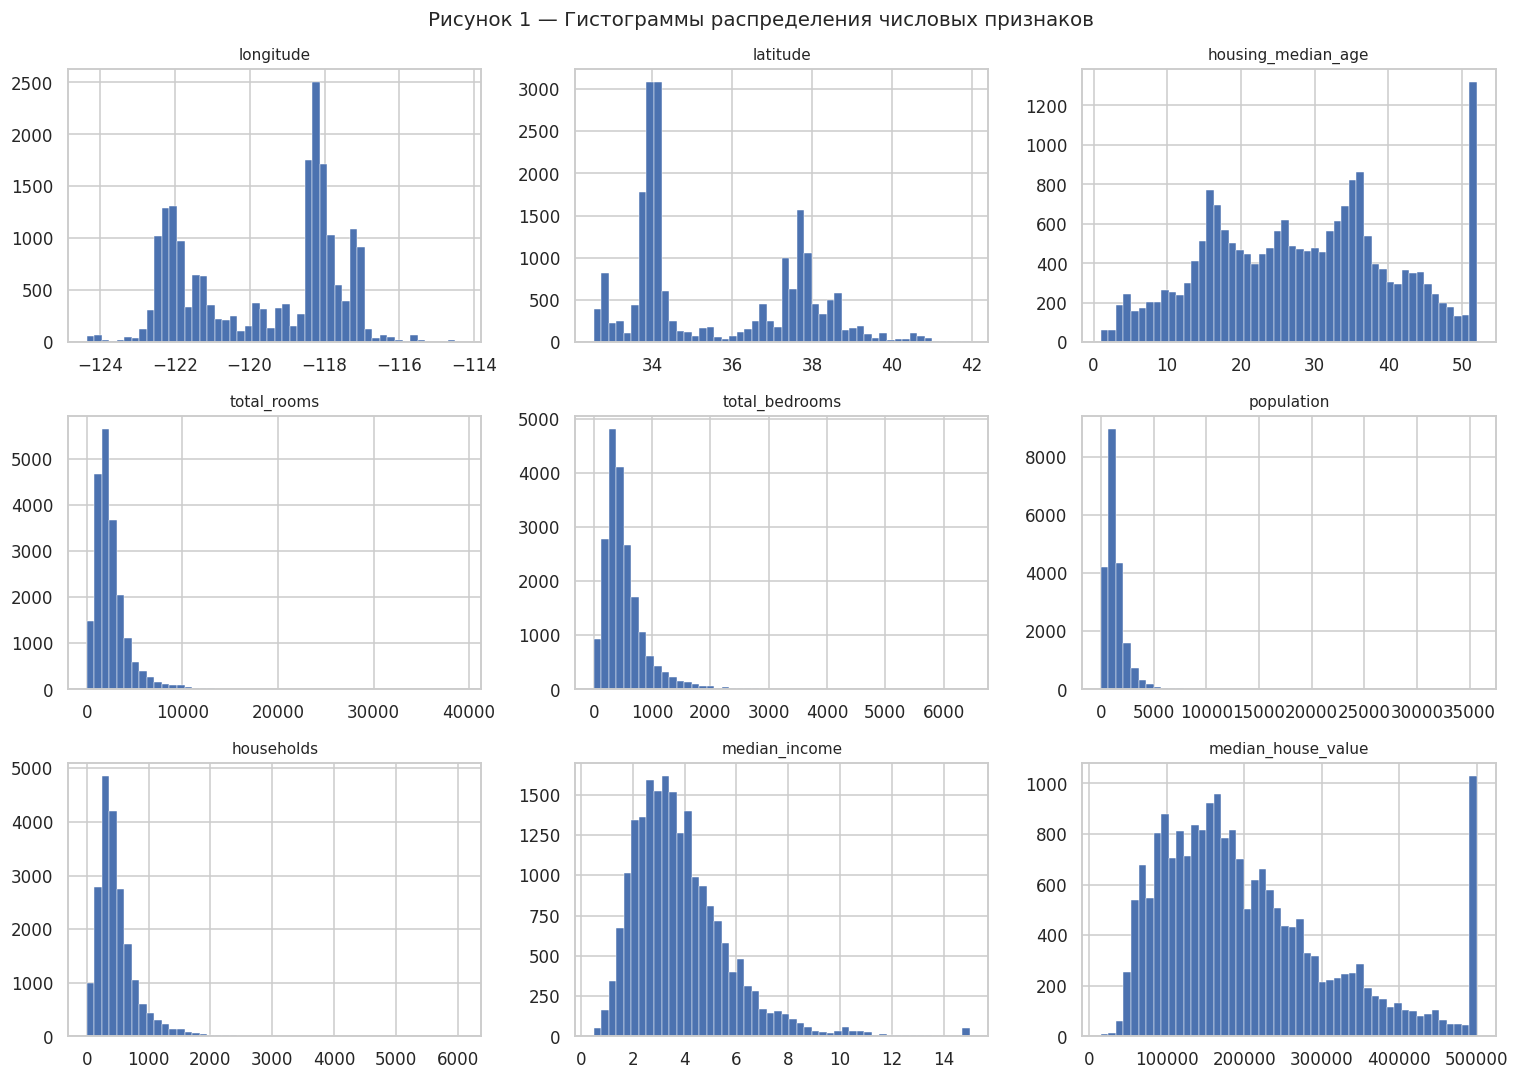

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(c, fontsize=10)
fig.suptitle("Рисунок 1 — Гистограммы распределения числовых признаков", fontsize=13)
fig.tight_layout()
plt.show()

Признаки `total_rooms`, `total_bedrooms`, `population` и `households` имеют выраженную
правостороннюю асимметрию и длинный «хвост» больших значений: это агрегаты по кварталу, размер
которого сильно варьируется. Признаки `housing_median_age` и `median_house_value` обрезаны сверху
(значения 52 года и 500 001 \$ соответственно), что видно по характерному столбцу на правом краю
гистограмм.

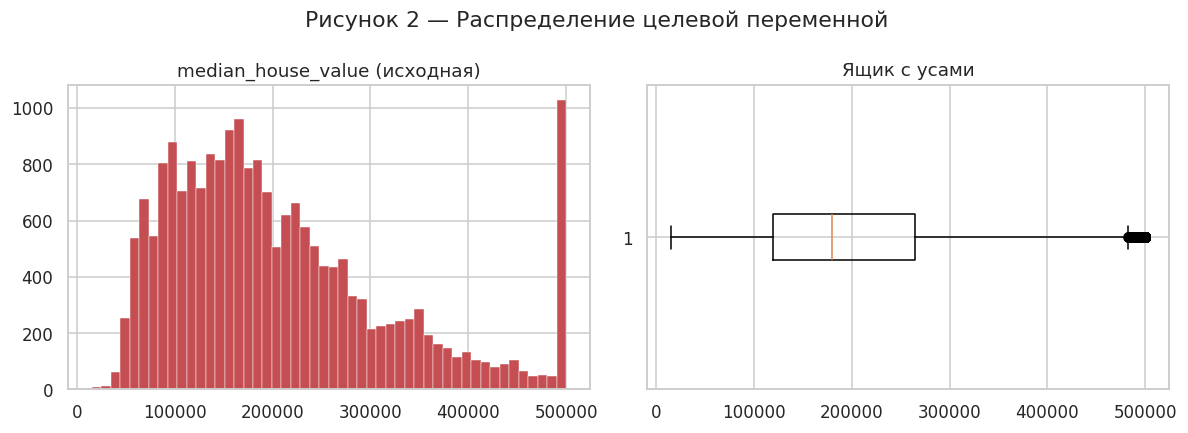

Наблюдений с обрезанным значением цены 500001 $: 965 (4.7 % выборки)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["median_house_value"], bins=50, color="#C44E52", edgecolor="white", linewidth=0.3)
axes[0].set_title("median_house_value (исходная)")
axes[1].boxplot(df["median_house_value"], vert=False)
axes[1].set_title("Ящик с усами")
fig.suptitle("Рисунок 2 — Распределение целевой переменной")
fig.tight_layout()
plt.show()

cap = df["median_house_value"].max()
n_cap = int((df["median_house_value"] >= cap).sum())
print(f"Наблюдений с обрезанным значением цены {cap:.0f} $: {n_cap} "
      f"({n_cap / len(df) * 100:.1f} % выборки)")

В выборке присутствует **965 наблюдений (4,7 %)** с искусственно обрезанным значением цены
500 001 \$. Такие наблюдения являются *цензурированными* и вносят систематическую ошибку
в регрессию, поэтому они будут удалены на этапе предобработки.

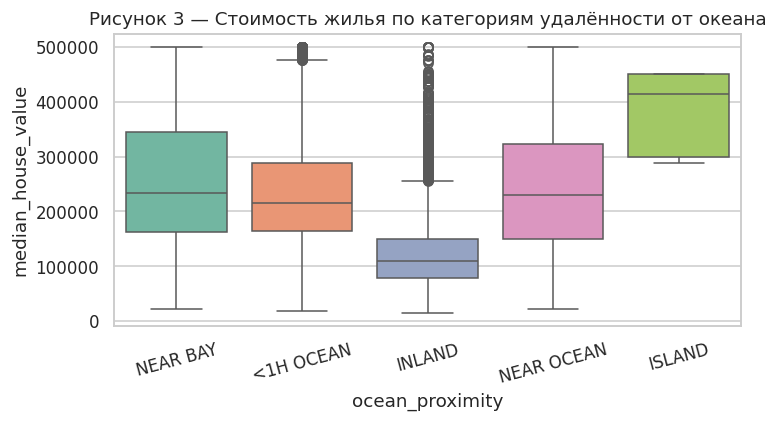

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax, palette="Set2")
ax.set_title("Рисунок 3 — Стоимость жилья по категориям удалённости от океана")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

Категория `INLAND` (внутренние районы штата) отчётливо отличается пониженным уровнем цен,
поэтому категориальный признак несёт полезную информацию и должен быть включён в модель.

<a id="3"></a>
# 3. Подготовка данных

Предобработка выполняется в следующем порядке.

1. **Удаление пропусков.** Пропуски есть только в `total_bedrooms` (207 значений, ~1 % выборки),
   соответствующие строки удаляются методом `dropna()`, поскольку их доля пренебрежимо мала.
   Альтернатива — заполнение медианой — здесь не даёт преимуществ.
2. **Удаление цензурированных значений** целевой переменной (965 наблюдений со значением 500 001 \$).
3. **Формирование производных признаков.** Абсолютные счётчики по кварталу малоинформативны сами
   по себе, поэтому дополнительно рассчитываются относительные показатели:
   `rooms_per_household`, `bedrooms_per_room`, `population_per_household`.
4. **Кодирование категориальной переменной.** Признак `ocean_proximity` кодируется методом
   one-hot (дамми-кодирование) с удалением первой категории (`drop_first=True`) во избежание
   полной линейной зависимости («ловушки фиктивных переменных»). Базовая категория — `<1H OCEAN`.
5. **Разделение выборки** на обучающую и тестовую в соотношении **80/20**
   (`train_test_split`, `random_state=42`).
6. **Нормализация (стандартизация).** Признаки имеют разный масштаб (доход — единицы, число
   комнат — тысячи), поэтому применяется `StandardScaler`: параметры среднего и стандартного
   отклонения рассчитываются **только на обучающей выборке** и затем применяются к тестовой,
   что исключает утечку данных. Стандартизация обязательна для гребневой регрессии и для PCA.

In [9]:
# 3.1-3.2 Удаление пропусков и цензурированных наблюдений
df = df.dropna().reset_index(drop=True)
df = df[df["median_house_value"] < cap].reset_index(drop=True)

# 3.3 Производные признаки
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# 3.4 One-hot кодирование категориального признака
df = pd.get_dummies(df, columns=["ocean_proximity"], prefix="op", drop_first=True, dtype=float)

TARGET = "median_house_value"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Размер после предобработки:", df.shape)
print("Число признаков:", X.shape[1])
print("Признаки:", list(X.columns))

Размер после предобработки: (19475, 16)
Число признаков: 15
Признаки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'op_INLAND', 'op_ISLAND', 'op_NEAR BAY', 'op_NEAR OCEAN']


In [10]:
# 3.5 Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка: ", X_test.shape)

# 3.6 Стандартизация (scaler обучается только на train)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("\nПосле стандартизации: среднее =", np.round(X_train_s.mean(), 6),
      " ст. отклонение =", np.round(X_train_s.std(), 6))

Обучающая выборка: (15580, 15)
Тестовая выборка:  (3895, 15)

После стандартизации: среднее = -0.0  ст. отклонение = 1.0


<a id="4"></a>
# 4. Ход работы

<a id="41"></a>
## 4.1. Корреляционный анализ

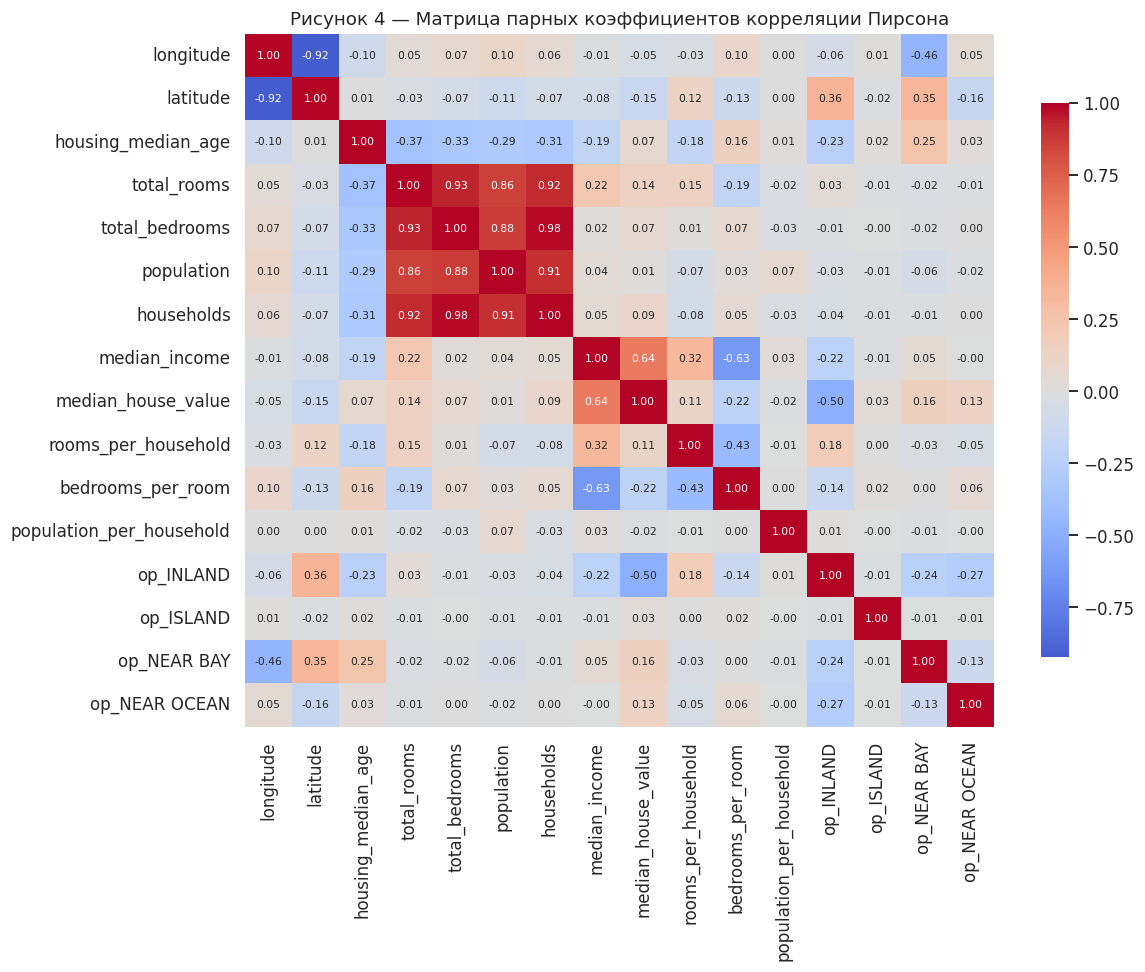

In [11]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Рисунок 4 — Матрица парных коэффициентов корреляции Пирсона")
fig.tight_layout()
plt.show()

In [12]:
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Таблица 2 — Корреляция признаков с целевой переменной:")
target_corr.round(3).to_frame("Коэффициент корреляции")

Таблица 2 — Корреляция признаков с целевой переменной:


,Коэффициент корреляции
median_income,0.643
op_INLAND,-0.499
bedrooms_per_room,-0.216
op_NEAR BAY,0.157
latitude,-0.149
total_rooms,0.142
op_NEAR OCEAN,0.135
rooms_per_household,0.109
households,0.094
total_bedrooms,0.075


Наиболее сильная связь с ценой жилья — у медианного дохода домохозяйства (r = 0,643) и у признака
принадлежности к внутренним районам штата (r = −0,499). Одновременно матрица показывает крайне
высокую взаимную корреляцию блока «размерных» признаков: `total_rooms`, `total_bedrooms`,
`population` и `households` связаны друг с другом на уровне r > 0,85, а долгота и широта —
на уровне r ≈ −0,92. **Это прямое указание на мультиколлинеарность.**

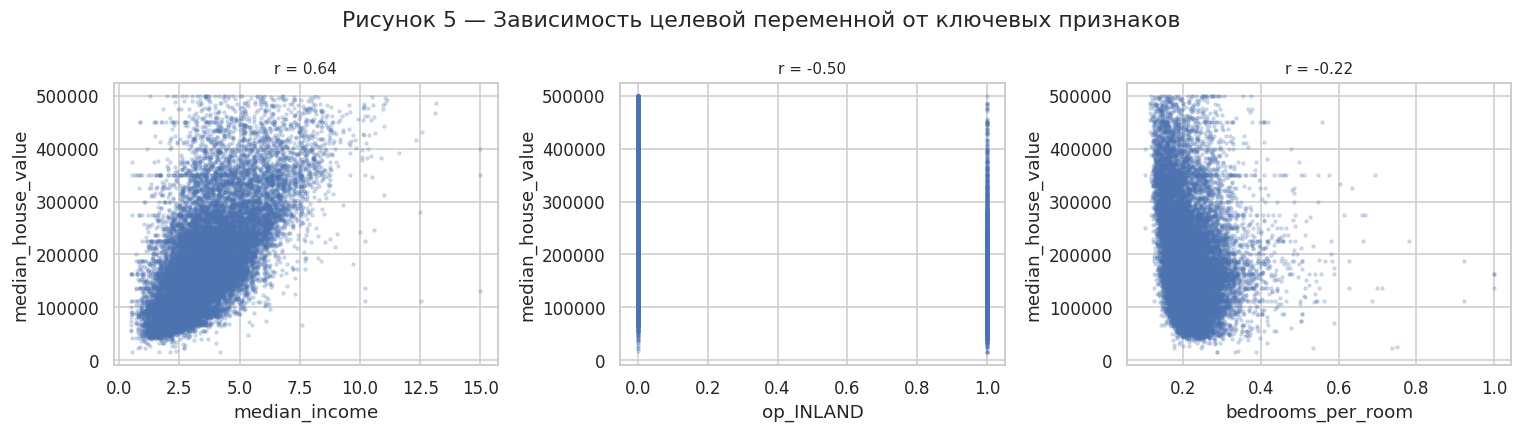

In [13]:
top3 = target_corr.abs().sort_values(ascending=False).index[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, top3):
    ax.scatter(df[c], y, s=4, alpha=0.2, color="#4C72B0")
    ax.set_xlabel(c); ax.set_ylabel(TARGET)
    ax.set_title(f"r = {corr.loc[c, TARGET]:.2f}", fontsize=10)
fig.suptitle("Рисунок 5 — Зависимость целевой переменной от ключевых признаков")
fig.tight_layout()
plt.show()

<a id="42"></a>
## 4.2. Оценка мультиколлинеарности: коэффициент VIF

Для количественной оценки мультиколлинеарности рассчитывается фактор инфляции дисперсии

$$VIF_j = \frac{1}{1 - R_j^2},$$

где $R_j^2$ — коэффициент детерминации регрессии $j$-го признака на все остальные.
Общепринятые пороги: VIF < 5 — мультиколлинеарность отсутствует, 5 ≤ VIF < 10 — умеренная,
VIF ≥ 10 — сильная.

In [14]:
def vif_table(X_df):
    Xs = StandardScaler().fit_transform(X_df)
    Xs = np.column_stack([np.ones(len(Xs)), Xs])
    t = pd.DataFrame({
        "Признак": X_df.columns,
        "VIF": [variance_inflation_factor(Xs, i + 1) for i in range(X_df.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    t["Мультиколлинеарность"] = np.where(t.VIF >= 10, "сильная",
                                  np.where(t.VIF >= 5, "умеренная", "нет"))
    return t

vif = vif_table(X)
print("Таблица 3 — Значения VIF для исходных признаков:")
vif.round(2)

Таблица 3 — Значения VIF для исходных признаков:


,Признак,VIF,Мультиколлинеарность
0,total_bedrooms,50.92,сильная
1,households,45.64,сильная
2,latitude,20.23,сильная
3,total_rooms,19.46,сильная
4,longitude,18.10,сильная
5,population,7.01,умеренная
6,op_INLAND,2.91,нет
7,bedrooms_per_room,2.85,нет
8,median_income,2.38,нет
9,rooms_per_household,1.84,нет


Пять признаков имеют VIF ≥ 10 (`total_bedrooms` — 50,92; `households` — 45,64; `latitude`,
`total_rooms`, `longitude`), ещё один (`population`) — умеренную мультиколлинеарность.
Следовательно, оценки коэффициентов линейной регрессии неустойчивы: их величины и знаки могут
сильно меняться при малом изменении выборки, а интерпретация отдельных коэффициентов теряет смысл.

<a id="43"></a>
## 4.3. Регрессионные модели на исходных признаках

Строятся две модели:

- **линейная регрессия** (метод наименьших квадратов) — минимизирует $\sum (y_i - \hat y_i)^2$;
- **гребневая регрессия** (Ridge, $L_2$-регуляризация) — минимизирует
  $\sum (y_i - \hat y_i)^2 + \alpha \sum \beta_j^2$, что уменьшает дисперсию оценок
  коэффициентов при коррелированных признаках.

Параметр $\alpha$ подбирается поиском по сетке из 40 значений в диапазоне $10^{-3} \dots 10^{4}$
с 5-блочной кросс-валидацией. Качество оценивается на отложенной тестовой выборке по метрикам
RMSE, R² и MAPE, а также по 5-блочной кросс-валидации на обучающей выборке.

In [15]:
def evaluate(model, Xtr, ytr, Xte, yte, name, store=None):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv, scoring="r2")
    cv_rmse = -cross_val_score(model, Xtr, ytr, cv=cv, scoring="neg_root_mean_squared_error")
    row = {
        "Модель": name,
        "RMSE": float(np.sqrt(mean_squared_error(yte, pred))),
        "R2": float(r2_score(yte, pred)),
        "MAPE, %": float(mean_absolute_percentage_error(yte, pred) * 100),
        "CV R2 (5-fold)": float(cv_r2.mean()),
        "CV RMSE (5-fold)": float(cv_rmse.mean()),
    }
    print(f"{name}:\n  RMSE = {row['RMSE']:.1f} $   R2 = {row['R2']:.4f}   "
          f"MAPE = {row['MAPE, %']:.2f} %   CV R2 = {row['CV R2 (5-fold)']:.4f}")
    if store is not None:
        store.append(row)
    return row, pred

results = []
lin = LinearRegression()
row_lin, pred_lin = evaluate(lin, X_train_s, y_train, X_test_s, y_test,
                             "Линейная регрессия (исходные признаки)", results)

Линейная регрессия (исходные признаки):
  RMSE = 60019.3 $   R2 = 0.6281   MAPE = 26.88 %   CV R2 = 0.6138


In [16]:
# Подбор alpha для гребневой регрессии
grid = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 4, 40)},
                    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
grid.fit(X_train_s, y_train)
best_alpha = grid.best_params_["alpha"]
print("Оптимальное alpha:", round(best_alpha, 3), "\n")

row_ridge, pred_ridge = evaluate(Ridge(alpha=best_alpha), X_train_s, y_train,
                                 X_test_s, y_test,
                                 "Гребневая регрессия (исходные признаки)", results)

Оптимальное alpha: 70.17 

Гребневая регрессия (исходные признаки):
  RMSE = 60038.2 $   R2 = 0.6278   MAPE = 26.76 %   CV R2 = 0.6143


In [17]:
print("Таблица 4 — Качество моделей на исходных признаках:")
pd.DataFrame(results).round(4)

Таблица 4 — Качество моделей на исходных признаках:


,Модель,RMSE,R2,"MAPE, %",CV R2 (5-fold),CV RMSE (5-fold)
0,Линейная регрессия (исходные признаки),60019.2578,0.6281,26.8798,0.6138,60574.0654
1,Гребневая регрессия (исходные признаки),60038.2189,0.6278,26.7571,0.6143,60536.1986


Обе модели дают практически одинаковый результат: **R² ≈ 0,63**, то есть модель объясняет около
63 % дисперсии цены жилья; средняя ошибка составляет около **60 тыс. \$** при среднем уровне цен
порядка 200 тыс. \$, относительная ошибка **MAPE ≈ 26,9 %**. Близость метрик на кросс-валидации
и на тестовой выборке (R² 0,6138 против 0,6281) говорит об отсутствии переобучения — модель
устойчива, но ограничена своей линейной природой.

Гребневая регрессия не дала выигрыша в точности, что закономерно: объём выборки (~15,6 тыс.
наблюдений) на три порядка превосходит число признаков (15), поэтому дисперсия оценок невелика
и регуляризация лишь незначительно смещает коэффициенты. Её эффект проявляется в другом —
коэффициенты коррелированных признаков становятся более устойчивыми.

In [18]:
coefs = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Таблица 5 — Коэффициенты линейной регрессии на стандартизованных признаках:")
coefs.round(1).to_frame("Коэффициент, $")

Таблица 5 — Коэффициенты линейной регрессии на стандартизованных признаках:


,"Коэффициент, $"
median_income,64792.3
longitude,-50834.6
latitude,-49234.7
population,-37533.3
households,29904.3
op_INLAND,-15983.4
bedrooms_per_room,14428.3
total_bedrooms,12350.1
housing_median_age,12156.6
rooms_per_household,4567.3


Обращает на себя внимание отрицательный коэффициент при `population` и положительный при
`households` при том, что парные корреляции обоих с ценой положительны и близки к нулю: это
типичное проявление мультиколлинеарности, когда сильно связанные признаки «делят» общий эффект
и получают противоположные по знаку веса.

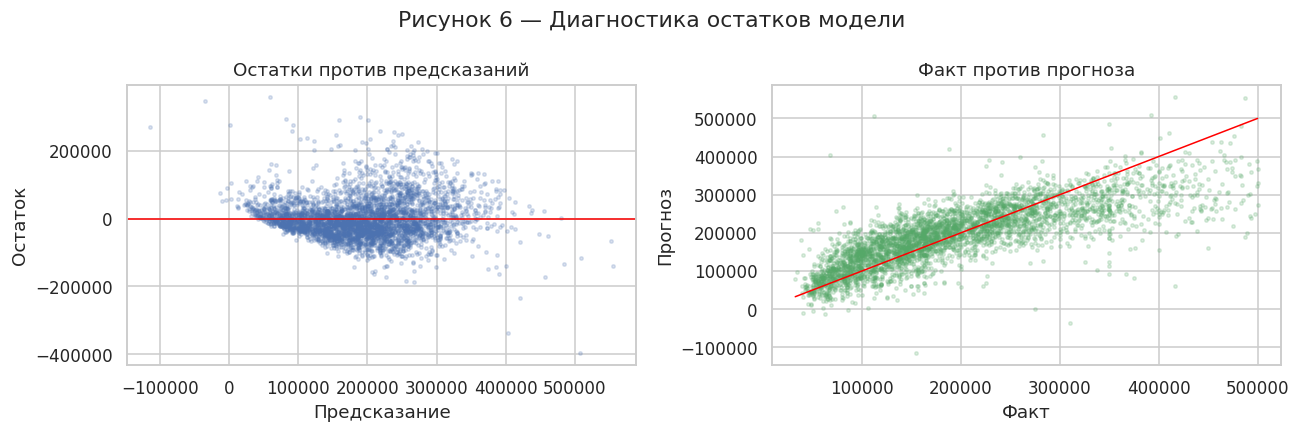

In [19]:
resid = y_test - pred_lin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_lin, resid, s=5, alpha=0.2, color="#4C72B0")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Предсказание"); axes[0].set_ylabel("Остаток")
axes[0].set_title("Остатки против предсказаний")
axes[1].scatter(y_test, pred_lin, s=5, alpha=0.2, color="#55A868")
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="red", lw=1)
axes[1].set_xlabel("Факт"); axes[1].set_ylabel("Прогноз")
axes[1].set_title("Факт против прогноза")
fig.suptitle("Рисунок 6 — Диагностика остатков модели")
fig.tight_layout()
plt.show()

График остатков показывает их неоднородность (**гетероскедастичность**): разброс ошибок растёт
с увеличением предсказанной цены, а для дорогих объектов модель систематически занижает прогноз.
Это ограничение линейной модели, которое не устраняется регуляризацией.

<a id="44"></a>
## 4.4. Устранение мультиколлинеарности: метод главных компонент

Для устранения мультиколлинеарности и снижения размерности применяется **метод главных компонент
(PCA)**. PCA строит новые признаки — линейные комбинации исходных, взаимно **ортогональные**
и упорядоченные по убыванию объясняемой дисперсии. Поскольку метод основан на матрице ковариаций
и чувствителен к масштабу, данные предварительно **стандартизованы** (`StandardScaler` обучен
на train-выборке, см. раздел 3).

In [20]:
pca_full = PCA().fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_comp = int(np.argmax(cum >= 0.95) + 1)

print("Таблица 6 — Объяснённая дисперсия главных компонент:")
tbl = pd.DataFrame({
    "Компонента": [f"PC{i+1}" for i in range(len(evr))],
    "Собств. значение": pca_full.explained_variance_.round(3),
    "Доля дисперсии": evr.round(4),
    "Накопленная доля": cum.round(4),
})
print(f"\nКомпонент для сохранения 95 % дисперсии: {n_comp}")
tbl

Таблица 6 — Объяснённая дисперсия главных компонент:

Компонент для сохранения 95 % дисперсии: 10


,Компонента,Собств. значение,Доля дисперсии,Накопленная доля
0,PC1,3.953,0.2635,0.2635
1,PC2,2.331,0.1554,0.4189
2,PC3,1.974,0.1316,0.5505
3,PC4,1.521,0.1014,0.6520
4,PC5,1.012,0.0675,0.7194
5,PC6,1.006,0.0671,0.7865
6,PC7,0.972,0.0648,0.8513
7,PC8,0.715,0.0477,0.8989
8,PC9,0.626,0.0417,0.9407
9,PC10,0.430,0.0287,0.9694


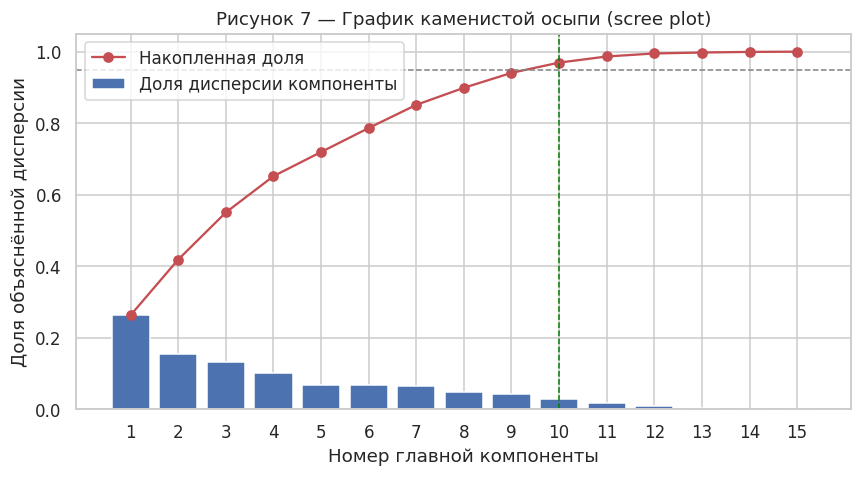

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(1, len(evr) + 1)
ax.bar(xs, evr, color="#4C72B0", label="Доля дисперсии компоненты")
ax.plot(xs, cum, "o-", color="#C44E52", label="Накопленная доля")
ax.axhline(0.95, ls="--", color="gray", lw=1)
ax.axvline(n_comp, ls="--", color="green", lw=1)
ax.set_xlabel("Номер главной компоненты"); ax.set_ylabel("Доля объяснённой дисперсии")
ax.set_title("Рисунок 7 — График каменистой осыпи (scree plot)")
ax.set_xticks(xs); ax.legend()
fig.tight_layout()
plt.show()

По **критерию Кайзера** (собственное значение > 1) следует оставить 6 компонент, по «правилу
локтя» на графике осыпи излом наблюдается на 4–5 компоненте. В работе использован критерий
**накопленной доли дисперсии 95 %**, которому соответствуют **10 главных компонент** —
размерность снижена с 15 до 10 при потере лишь 5 % исходной информации.

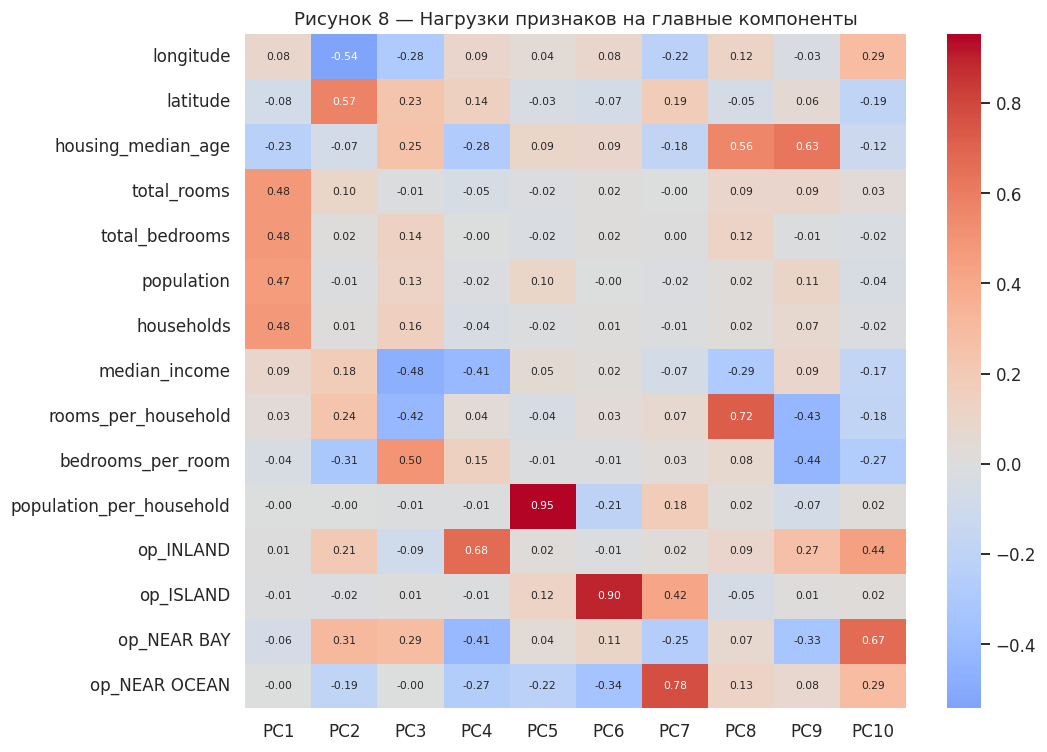

In [22]:
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

loadings = pd.DataFrame(pca.components_.T, index=X.columns,
                        columns=[f"PC{i+1}" for i in range(n_comp)])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Рисунок 8 — Нагрузки признаков на главные компоненты")
fig.tight_layout()
plt.show()

In [23]:
# Проверка: мультиколлинеарность после PCA
vif_pca = vif_table(pd.DataFrame(X_train_p, columns=loadings.columns))
print("VIF главных компонент:")
vif_pca.round(3)

VIF главных компонент:


,Признак,VIF,Мультиколлинеарность
0,PC1,1.0,нет
1,PC3,1.0,нет
2,PC10,1.0,нет
3,PC4,1.0,нет
4,PC9,1.0,нет
5,PC8,1.0,нет
6,PC2,1.0,нет
7,PC5,1.0,нет
8,PC6,1.0,нет
9,PC7,1.0,нет


Первая компонента (26,4 % дисперсии) объединяет «размерные» признаки квартала — `total_rooms`,
`total_bedrooms`, `population`, `households` — и фактически представляет собой обобщённый «размер
квартала». Вторая компонента описывает географическое положение (долгота — широта), третья —
структуру жилья (доля спален, комнат на домохозяйство). Таким образом, PCA свернул группы
коррелированных признаков в отдельные независимые факторы.

После преобразования значения **VIF для всех главных компонент равны 1,00**, то есть
мультиколлинеарность устранена полностью — это прямое следствие ортогональности компонент.

<a id="45"></a>
## 4.5. Регрессия на главных компонентах и сравнение моделей

На выделенных 10 главных компонентах повторно обучаются обе модели по той же схеме.

In [24]:
row_lin_p, _ = evaluate(LinearRegression(), X_train_p, y_train, X_test_p, y_test,
                        f"Линейная регрессия (PCA, {n_comp} компонент)", results)

grid_p = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 4, 40)},
                      cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
grid_p.fit(X_train_p, y_train)
alpha_p = grid_p.best_params_["alpha"]
print("\nОптимальное alpha (PCA):", round(alpha_p, 3), "\n")

row_ridge_p, _ = evaluate(Ridge(alpha=alpha_p), X_train_p, y_train, X_test_p, y_test,
                          f"Гребневая регрессия (PCA, {n_comp} компонент)", results)

Линейная регрессия (PCA, 10 компонент):
  RMSE = 66711.2 $   R2 = 0.5405   MAPE = 29.19 %   CV R2 = 0.5216



Оптимальное alpha (PCA): 366.524 

Гребневая регрессия (PCA, 10 компонент):
  RMSE = 66724.3 $   R2 = 0.5403   MAPE = 29.29 %   CV R2 = 0.5219


In [25]:
metrics = pd.DataFrame(results).round(4)
print("Таблица 7 — Сравнение качества моделей до и после PCA:")
metrics

Таблица 7 — Сравнение качества моделей до и после PCA:


,Модель,RMSE,R2,"MAPE, %",CV R2 (5-fold),CV RMSE (5-fold)
0,Линейная регрессия (исходные признаки),60019.2578,0.6281,26.8798,0.6138,60574.0654
1,Гребневая регрессия (исходные признаки),60038.2189,0.6278,26.7571,0.6143,60536.1986
2,"Линейная регрессия (PCA, 10 компонент)",66711.2136,0.5405,29.1910,0.5216,67436.0946
3,"Гребневая регрессия (PCA, 10 компонент)",66724.3067,0.5403,29.2925,0.5219,67415.6595


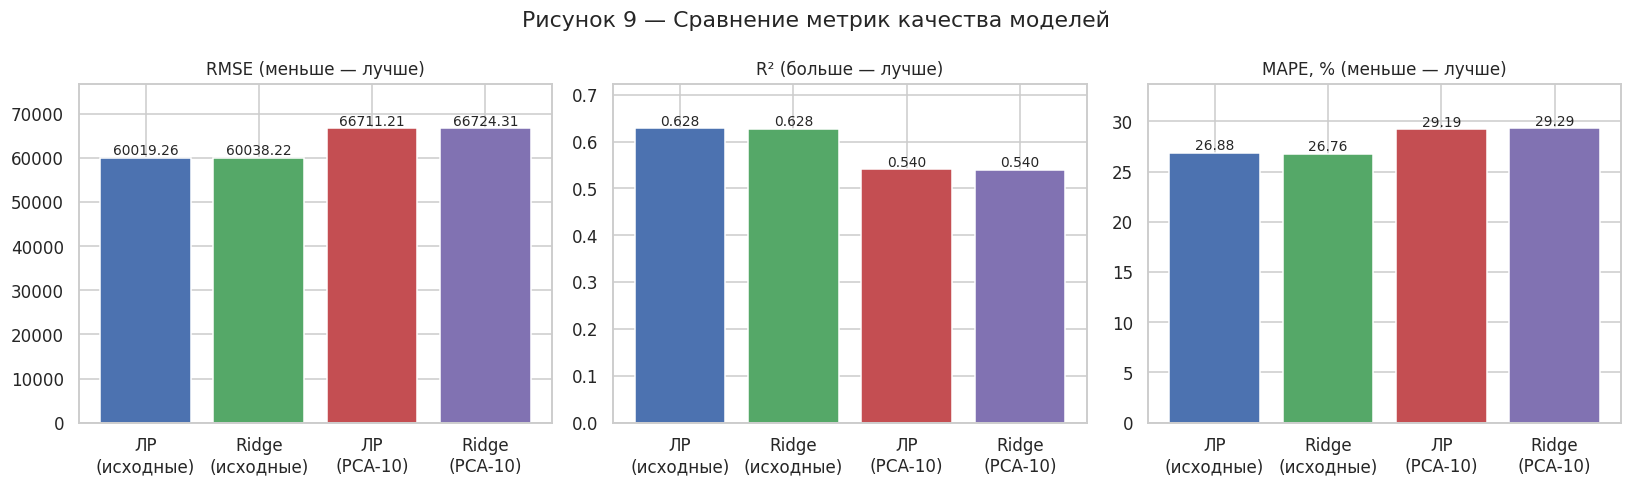

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
names = ["ЛР\n(исходные)", "Ridge\n(исходные)", f"ЛР\n(PCA-{n_comp})", f"Ridge\n(PCA-{n_comp})"]
for ax, col, ttl in zip(axes, ["RMSE", "R2", "MAPE, %"],
                        ["RMSE (меньше — лучше)", "R² (больше — лучше)",
                         "MAPE, % (меньше — лучше)"]):
    bars = ax.bar(names, metrics[col], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
    ax.set_title(ttl, fontsize=11)
    ax.bar_label(bars, fmt="%.3f" if col == "R2" else "%.2f", fontsize=9)
    ax.margins(y=0.15)
fig.suptitle("Рисунок 9 — Сравнение метрик качества моделей")
fig.tight_layout()
plt.show()

Модели на главных компонентах **уступили** исходным: R² снизился с 0,6281 до 0,5405,
RMSE вырос с 60 019 до 66 711 \$ (+11,15 %), MAPE — с 26,88 % до 29,19 %.

Результат закономерен: PCA является методом **обучения без учителя** и максимизирует объяснённую
дисперсию признаков, ничего не зная о целевой переменной. Отброшенные компоненты с малой
дисперсией оказались информативными для прогноза цены. Проверим это напрямую.

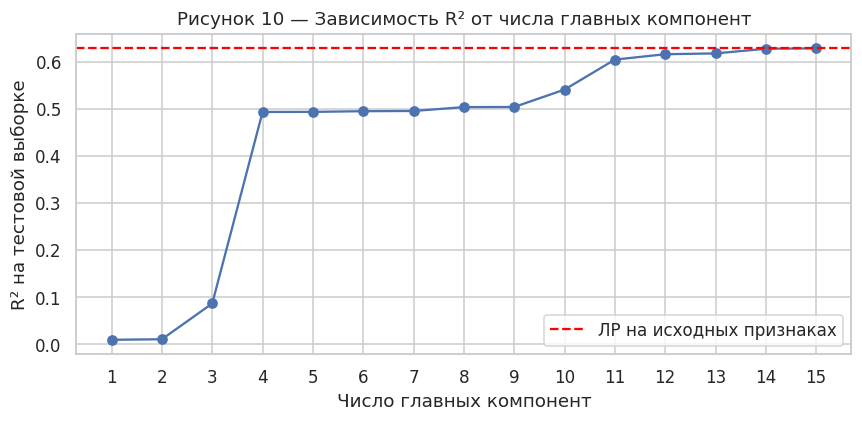

R² по числу компонент: [0.01  0.011 0.087 0.493 0.493 0.495 0.495 0.503 0.504 0.54  0.604 0.616
 0.617 0.627 0.628]


In [27]:
scores = []
for k in range(1, X_train_s.shape[1] + 1):
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_s)
    m = LinearRegression().fit(p.transform(X_train_s), y_train)
    scores.append(r2_score(y_test, m.predict(p.transform(X_test_s))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(scores) + 1), scores, "o-", color="#4C72B0")
ax.axhline(row_lin["R2"], ls="--", color="red", label="ЛР на исходных признаках")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R² на тестовой выборке")
ax.set_title("Рисунок 10 — Зависимость R² от числа главных компонент")
ax.legend(); ax.set_xticks(range(1, len(scores) + 1))
fig.tight_layout()
plt.show()

print("R² по числу компонент:", np.round(scores, 3))

Эксперимент подтверждает вывод: рост качества происходит скачками при добавлении 4-й, 11-й и 14-й
компонент, и только при использовании **всех 15** компонент модель полностью повторяет результат
регрессии на исходных признаках (R² = 0,628). В частности, 11-я компонента, объясняющая менее 2 %
дисперсии признаков, даёт прирост R² примерно на 0,06 — то есть является одной из самых полезных
для прогноза, хотя по критерию дисперсии была отброшена.

<a id="5"></a>
# 5. Заключение

В ходе работы на реальном датасете **California Housing Prices** (20 640 наблюдений) были
построены и исследованы модели линейной и гребневой регрессии, а также выполнено снижение
размерности методом главных компонент. Получены следующие результаты.

1. Проведён первичный анализ и предобработка данных: удалены пропуски (207 строк)
   и цензурированные наблюдения (965 строк), добавлены относительные производные признаки,
   категориальная переменная закодирована методом one-hot, выполнена стандартизация.
2. Корреляционный анализ и расчёт VIF выявили **сильную мультиколлинеарность**: у пяти признаков
   VIF превышает 10 (максимум — 50,92), что делает оценки коэффициентов неустойчивыми,
   а их интерпретацию некорректной.
3. Линейная регрессия на исходных признаках показала **RMSE = 60 019 \$, R² = 0,6281,
   MAPE = 26,88 %**. Гребневая регрессия с оптимальным α = 70,2 дала практически идентичный
   результат, так как при значительном превышении числа наблюдений над числом признаков
   регуляризация почти не влияет на точность.
4. Метод главных компонент полностью устранил мультиколлинеарность (VIF всех компонент = 1,00)
   и снизил размерность с 15 до 10 признаков при сохранении 95 % дисперсии, однако точность
   прогноза при этом ухудшилась: **R² = 0,5405, RMSE = 66 711 \$, MAPE = 29,19 %**.

**Основной вывод:** устранение мультиколлинеарности с помощью PCA улучшает статистические
свойства модели (устойчивость оценок, отсутствие коррелированных предикторов), но **не является
средством повышения точности прогноза**. Поскольку PCA не использует информацию о целевой
переменной, отбрасываемые компоненты с малой дисперсией могут оказаться значимыми для прогноза,
что и наблюдалось в данном эксперименте. Если приоритетом является точность, разумнее применять
гребневую регрессию на исходных признаках: она справляется с мультиколлинеарностью без потери
информации.

Достигнутый уровень R² ≈ 0,63 ограничен прежде всего **линейностью модели**: анализ остатков
показал гетероскедастичность и систематическое занижение прогноза для дорогого жилья. Возможные
направления повышения точности — логарифмирование целевой переменной и «хвостатых» признаков,
добавление нелинейных и пространственных признаков (расстояние до крупных городов, кластеризация
по координатам), а также переход к нелинейным моделям (градиентный бустинг, случайный лес).

<a id="6"></a>
# 6. Список источников

1. California Housing Prices [Электронный ресурс] // Kaggle. — URL:
   https://www.kaggle.com/datasets/camnugent/california-housing-prices
   (дата обращения: 18.09.2026).
2. Pace R. K., Barry R. Sparse Spatial Autoregressions // Statistics and Probability Letters. —
   1997. — Vol. 33, № 3. — P. 291–297.
3. Scikit-learn: Machine Learning in Python: документация [Электронный ресурс]. — URL:
   https://scikit-learn.org/stable/ (дата обращения: 18.09.2026).
4. Джеймс Г., Уиттон Д., Хасти Т., Тибширани Р. Введение в статистическое обучение с примерами
   на языке R. — М.: ДМК Пресс, 2017. — 456 с.
5. Жерон О. Прикладное машинное обучение с помощью Scikit-Learn, Keras и TensorFlow. — 2-е изд. —
   М.: Диалектика, 2020. — 1040 с.
6. Кутнер М., Нахтсхайм К., Нетер Дж. Прикладные линейные регрессионные модели. — 4-е изд. —
   McGraw-Hill, 2004. — 701 с.
7. Statsmodels: statistics in Python: документация [Электронный ресурс]. — URL:
   https://www.statsmodels.org/stable/ (дата обращения: 18.09.2026).

<a id="7"></a>
# 7. Приложение. Листинг программного кода

Ниже приведён полный листинг программы в виде единого скрипта `lab1.py`, выполняющего все этапы работы и сохраняющего графики в папку `figs/`. Код, разбитый по разделам, приведён в ячейках выше.

```python
# %% [markdown]
# # Лабораторная работа 1. Линейная регрессия и факторный анализ
# Датасет: California Housing Prices (Kaggle: camnugent/california-housing-prices)
# Целевая переменная: median_house_value — медианная стоимость дома в квартале.

# %% Импорт библиотек
import os
import sys
import urllib.request
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

# Рабочая папка = папка со скриптом (чтобы пути не зависели от способа запуска)
try:
    os.chdir(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    pass  # запуск в Jupyter — рабочая папка уже верная

FIG = "figs/"
os.makedirs(FIG, exist_ok=True)
RES = {}

# %% 1. Загрузка данных
CSV = "housing.csv"
URL = ("https://raw.githubusercontent.com/ageron/handson-ml2/"
       "master/datasets/housing/housing.csv")
if not os.path.exists(CSV):
    print("Файл не найден, скачиваем датасет...")
    try:
        urllib.request.urlretrieve(URL, CSV)
    except Exception as e:
        sys.exit(f"Не удалось скачать датасет ({e}). "
                 f"Скачайте вручную по ссылке {URL} и положите файл рядом со скриптом.")

df = pd.read_csv(CSV)
print("Размер датасета:", df.shape)
print(df.head())
print(df.info())
print(df.describe().T)
RES["shape_raw"] = list(df.shape)
RES["describe"] = df.describe().T.round(2).to_dict()

# %% 2. Первичный анализ: пропуски
na = df.isna().sum()
print("Пропуски:\n", na[na > 0])
RES["na"] = na[na > 0].to_dict()
print("Дубликаты:", df.duplicated().sum())
RES["dupl"] = int(df.duplicated().sum())
RES["cat_counts"] = df["ocean_proximity"].value_counts().to_dict()

# %% 2.1 Распределения признаков
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(c, fontsize=10)
fig.suptitle("Распределение числовых признаков", fontsize=13)
fig.tight_layout()
fig.savefig(FIG + "01_hist.png", bbox_inches="tight")
plt.close(fig)

# %% 2.2 Целевая переменная
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["median_house_value"], bins=50, color="#C44E52", edgecolor="white", linewidth=0.3)
axes[0].set_title("median_house_value (исходная)")
axes[1].boxplot(df["median_house_value"], vert=False)
axes[1].set_title("Ящик с усами")
fig.tight_layout()
fig.savefig(FIG + "02_target.png", bbox_inches="tight")
plt.close(fig)

# %% 2.3 Категориальный признак
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax, palette="Set2")
ax.set_title("Стоимость жилья по категории удалённости от океана")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIG + "03_cat.png", bbox_inches="tight")
plt.close(fig)

# %% 3. Предобработка
# 3.1 Удаление пропусков (207 строк в total_bedrooms — менее 1 % выборки)
df = df.dropna().reset_index(drop=True)

# 3.2 Удаление "цензурированных" наблюдений (значения обрезаны сверху на 500001)
cap = df["median_house_value"].max()
n_cap = int((df["median_house_value"] >= cap).sum())
RES["cap_value"], RES["n_cap"] = float(cap), n_cap
df = df[df["median_house_value"] < cap].reset_index(drop=True)

# 3.3 Производные признаки (нормировка на размер квартала)
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

# 3.4 Кодирование категориальной переменной (one-hot, dummy-кодирование)
df = pd.get_dummies(df, columns=["ocean_proximity"], prefix="op", drop_first=True, dtype=float)

TARGET = "median_house_value"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print("Размер после предобработки:", df.shape)
print("Признаки:", list(X.columns))
RES["shape_clean"] = list(df.shape)
RES["features"] = list(X.columns)

# %% 4. Корреляционный анализ
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Матрица корреляций (Пирсон)")
fig.tight_layout()
fig.savefig(FIG + "04_corr.png", bbox_inches="tight")
plt.close(fig)

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Корреляция с целевой переменной:\n", target_corr.round(3))
RES["target_corr"] = target_corr.round(3).to_dict()

# %% 4.1 Диаграммы рассеяния с наиболее значимыми признаками
top3 = target_corr.abs().sort_values(ascending=False).index[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, top3):
    ax.scatter(df[c], y, s=4, alpha=0.2, color="#4C72B0")
    ax.set_xlabel(c); ax.set_ylabel(TARGET)
    ax.set_title(f"r = {corr.loc[c, TARGET]:.2f}", fontsize=10)
fig.suptitle("Зависимость целевой переменной от ключевых признаков")
fig.tight_layout()
fig.savefig(FIG + "05_scatter.png", bbox_inches="tight")
plt.close(fig)

# %% 4.2 Расчёт VIF (фактор инфляции дисперсии)
def vif_table(X_df):
    Xs = StandardScaler().fit_transform(X_df)
    Xs = np.column_stack([np.ones(len(Xs)), Xs])
    return pd.DataFrame({
        "Признак": X_df.columns,
        "VIF": [variance_inflation_factor(Xs, i + 1) for i in range(X_df.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

vif = vif_table(X)
print(vif.round(2))
RES["vif"] = vif.round(2).to_dict("records")

# %% 5. Разделение выборки и стандартизация
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("train:", X_train.shape, " test:", X_test.shape)
RES["split"] = {"train": list(X_train.shape), "test": list(X_test.shape)}

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# %% 5.1 Функция оценки качества
def evaluate(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv, scoring="r2")
    cv_rmse = -cross_val_score(model, Xtr, ytr, cv=cv, scoring="neg_root_mean_squared_error")
    row = {
        "Модель": name,
        "RMSE": float(np.sqrt(mean_squared_error(yte, pred))),
        "R2": float(r2_score(yte, pred)),
        "MAPE, %": float(mean_absolute_percentage_error(yte, pred) * 100),
        "CV R2 (5-fold)": float(cv_r2.mean()),
        "CV RMSE (5-fold)": float(cv_rmse.mean()),
    }
    print(f"{name}: RMSE={row['RMSE']:.1f}  R2={row['R2']:.4f}  "
          f"MAPE={row['MAPE, %']:.2f}%  CV R2={row['CV R2 (5-fold)']:.4f}")
    return row, pred

results = []

# %% 5.2 Линейная регрессия на исходных признаках
lin = LinearRegression()
row_lin, pred_lin = evaluate(lin, X_train_s, y_train, X_test_s, y_test,
                             "Линейная регрессия (исходные признаки)")
results.append(row_lin)

coefs = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Коэффициенты (на стандартизованных данных):\n", coefs.round(1))
RES["coefs"] = coefs.round(1).to_dict()

# %% 5.3 Гребневая регрессия (подбор alpha по сетке с кросс-валидацией)
grid = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 4, 40)},
                    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
grid.fit(X_train_s, y_train)
best_alpha = grid.best_params_["alpha"]
print("Лучшее alpha:", round(best_alpha, 4))
RES["best_alpha"] = float(best_alpha)

row_ridge, pred_ridge = evaluate(Ridge(alpha=best_alpha), X_train_s, y_train,
                                 X_test_s, y_test, "Гребневая регрессия (исходные признаки)")
results.append(row_ridge)

# %% 5.4 Диагностика остатков
resid = y_test - pred_lin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_lin, resid, s=5, alpha=0.2, color="#4C72B0")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Предсказание"); axes[0].set_ylabel("Остаток")
axes[0].set_title("Остатки против предсказаний")
axes[1].scatter(y_test, pred_lin, s=5, alpha=0.2, color="#55A868")
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="red", lw=1)
axes[1].set_xlabel("Факт"); axes[1].set_ylabel("Прогноз")
axes[1].set_title("Факт против прогноза")
fig.tight_layout()
fig.savefig(FIG + "06_resid.png", bbox_inches="tight")
plt.close(fig)

# %% 6. Метод главных компонент (PCA)
pca_full = PCA().fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_comp = int(np.argmax(cum >= 0.95) + 1)
print("Доля объяснённой дисперсии:", np.round(evr, 3))
print("Накопленная:", np.round(cum, 3))
print("Компонент для 95 % дисперсии:", n_comp)
RES["evr"] = [float(v) for v in evr]
RES["cum"] = [float(v) for v in cum]
RES["n_comp"] = n_comp
RES["eigenvalues"] = [float(v) for v in pca_full.explained_variance_]

# %% 6.1 График каменистой осыпи (scree plot)
fig, ax = plt.subplots(figsize=(8, 4.5))
xs = np.arange(1, len(evr) + 1)
ax.bar(xs, evr, color="#4C72B0", label="Доля дисперсии компоненты")
ax.plot(xs, cum, "o-", color="#C44E52", label="Накопленная доля")
ax.axhline(0.95, ls="--", color="gray", lw=1)
ax.axvline(n_comp, ls="--", color="green", lw=1)
ax.set_xlabel("Номер главной компоненты"); ax.set_ylabel("Доля объяснённой дисперсии")
ax.set_title("График каменистой осыпи (scree plot)")
ax.set_xticks(xs); ax.legend()
fig.tight_layout()
fig.savefig(FIG + "07_scree.png", bbox_inches="tight")
plt.close(fig)

# %% 6.2 Матрица нагрузок первых компонент
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

loadings = pd.DataFrame(pca.components_.T,
                        index=X.columns,
                        columns=[f"PC{i+1}" for i in range(n_comp)])
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Нагрузки признаков на главные компоненты")
fig.tight_layout()
fig.savefig(FIG + "08_loadings.png", bbox_inches="tight")
plt.close(fig)
RES["loadings"] = loadings.round(2).to_dict()

# VIF после PCA (компоненты ортогональны -> VIF ~ 1)
vif_pca = vif_table(pd.DataFrame(X_train_p, columns=loadings.columns))
print(vif_pca.round(3))
RES["vif_pca"] = vif_pca.round(3).to_dict("records")

# %% 7. Регрессия на главных компонентах
row_lin_p, _ = evaluate(LinearRegression(), X_train_p, y_train, X_test_p, y_test,
                        f"Линейная регрессия (PCA, {n_comp} компонент)")
results.append(row_lin_p)

grid_p = GridSearchCV(Ridge(), {"alpha": np.logspace(-3, 4, 40)},
                      cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
grid_p.fit(X_train_p, y_train)
alpha_p = grid_p.best_params_["alpha"]
RES["best_alpha_pca"] = float(alpha_p)
row_ridge_p, _ = evaluate(Ridge(alpha=alpha_p), X_train_p, y_train, X_test_p, y_test,
                          f"Гребневая регрессия (PCA, {n_comp} компонент)")
results.append(row_ridge_p)

# %% 7.1 Сводная таблица метрик
metrics = pd.DataFrame(results).round(4)
print(metrics.to_string(index=False))
metrics.to_csv("metrics.csv", index=False, encoding="utf-8-sig")
RES["metrics"] = metrics.to_dict("records")

# %% 7.2 Сравнение метрик графически
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
names = ["ЛР\n(исходные)", "Ridge\n(исходные)", f"ЛР\n(PCA-{n_comp})", f"Ridge\n(PCA-{n_comp})"]
for ax, col, ttl in zip(axes, ["RMSE", "R2", "MAPE, %"], ["RMSE (меньше — лучше)",
                                                          "R² (больше — лучше)",
                                                          "MAPE, % (меньше — лучше)"]):
    bars = ax.bar(names, metrics[col], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
    ax.set_title(ttl, fontsize=11)
    ax.bar_label(bars, fmt="%.3f" if col == "R2" else "%.2f", fontsize=9)
    ax.margins(y=0.15)
fig.suptitle("Сравнение качества моделей до и после PCA")
fig.tight_layout()
fig.savefig(FIG + "09_metrics.png", bbox_inches="tight")
plt.close(fig)

# %% 7.3 Зависимость качества от числа компонент
scores = []
for k in range(1, X_train_s.shape[1] + 1):
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_s)
    m = LinearRegression().fit(p.transform(X_train_s), y_train)
    scores.append(r2_score(y_test, m.predict(p.transform(X_test_s))))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(scores) + 1), scores, "o-", color="#4C72B0")
ax.axhline(row_lin["R2"], ls="--", color="red", label="ЛР на исходных признаках")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R² на тестовой выборке")
ax.set_title("Качество модели в зависимости от числа компонент")
ax.legend(); ax.set_xticks(range(1, len(scores) + 1))
fig.tight_layout()
fig.savefig(FIG + "10_r2_vs_k.png", bbox_inches="tight")
plt.close(fig)
RES["r2_vs_k"] = [float(s) for s in scores]

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(RES, f, ensure_ascii=False, indent=1, default=str)
print("Готово.")

```